Predictions is the bread and butter of Machine Learning. However, the connection between data and reality often involves a leap of faith where we gather insights about our sample and turn them into statements about the real world. Have you ever built a recommender system and thought twice about *why* it would drive engagement? Considered whether your predictions really are valid decision support?

This problem is common for all natural sciences and is called the *problem of induction*. One way of justifying this leap is to make assumptions about the real world or the data generating process (DGP). This makes Bayesian stats a little "more inductive" than Frequentist in my humble opinion, since we include a subjective prior assumption that clearly ties descriptive sample statistics back to (our subjective) reality.

Without getting too philosophical, the branch of statistics aiming to take induction to its limits is causal inference. Causality is the study of why things happen, and what would have happened otherwise. The main difference lies in its attention to the DGP. An analysis starts with a causal directed acyclic graph (DAG) encoding assumptions about what affects what causally. The goal is to reason about counterfactuals and directly estimate what impact our decisions will have. Maybe the avocado toast of Machine Learning?

There is way too much on this topic to mention here but the two main cases to be aware of are confounders and mediators.

Consider the causal impact of T on Y, where X and M are some other measurable quantities.

```{dot}
digraph DAG {
  label = "X confounder, M mediator"
  X [shape=box]
  T [shape=box]
  M [shape=box]
  Y [shape=box]

  X -> {T,Y}
  T -> {M,Y}
  M -> Y

}
```

Confounders are variables that affect both the treatment and the outcome. Mediators are variables that affect the outcome as a consequence of the treatment. Rule of thumb, control for confounders but not mediators.

Take for example the causal impact of ice cream sales on drowning accidents. There is of course none, which you can discover by controlling for the confounder *weather*. Mediators are more complex, these variables can obscure the true causal relationship if you control for them since they absorb some of the causal pathway from the treatment to the outcome. In a sociology study, if you include socioeconomic status and the treatment is one of the variables used to calculate that status, the socioeconomic status could act as a mediator.

These deliberations about causal pathways underlying reality is the essence of causal inference. The rest is statistics as usual as we will see.

In [1]:
import pandas as pd
import numpy as np
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
sns.set_style("ticks")
sns.color_palette("dark")
plt.rc("axes.spines", top=False, right=False)
plt.rc("figure", figsize= (12,8))

[This Kaggle user](https://www.kaggle.com/datasets/neuromusic/avocado-prices/data) posed the question whether the US milennial housing crisis is caused by frivolous spending on avocado toast. I'm skeptical, and in any case I'd need some data on age breakdowns, credit scores and wages vs inflation to even begin looking into it. Let's instead pretend we're a US avocado monopolist trying to squeeze every last penny out of those entitled milennials. What is the market price elasticity of avocados in the US?

In [2]:
import kagglehub

path = kagglehub.dataset_download("neuromusic/avocado-prices")
path = pathlib.Path(path, "avocado.csv")
df=pd.read_csv(path, index_col=0).reset_index().drop("index", axis=1)

In [3]:
df

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


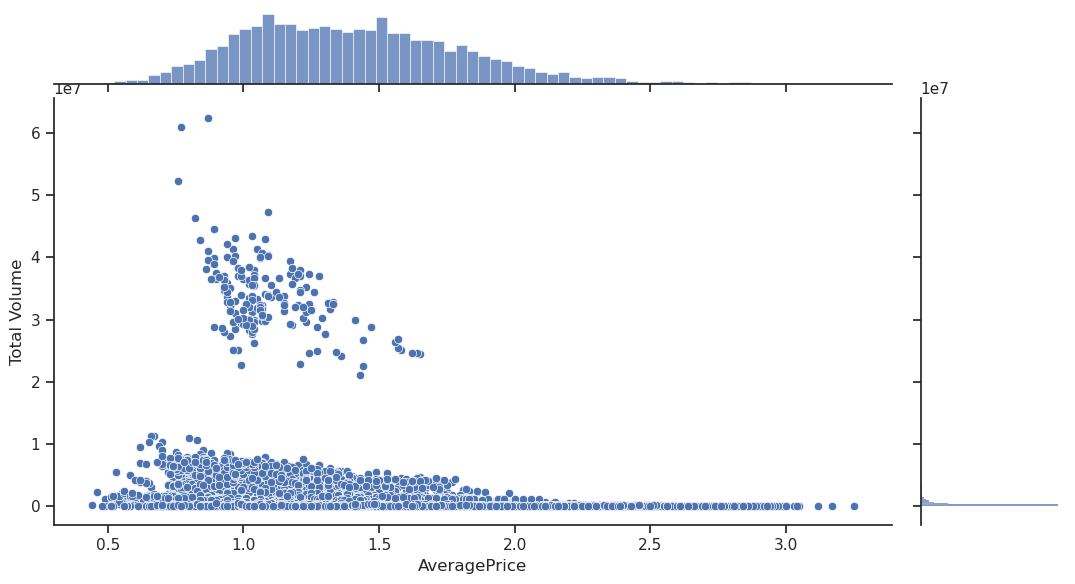

In [4]:
plot=sns.jointplot(data=df, x="AveragePrice",y="Total Volume");
plot.fig.set_figwidth(12)

We have some very disparate regions with a wide range of sales (the aggregate US is one of them). Also, econometric theory commonly assumes a sales to price relationship of the form $\text{volume} \propto \text{price}^q$, so let's assume the basic model 

$$\log{\text{volume}} = \beta_0 + \beta_1 \log{\text{price}} + \varepsilon$$

Volume and price will refer to their log transform from now on.

In [5]:
Y = np.log(df['Total Volume'])
X = df.drop(['AveragePrice','Total Volume'], axis=1)
T = np.log(df['AveragePrice'])

In [6]:
X['PropSmall'] = (X['Small Bags'] / X['Total Bags']).fillna(1)
X['4046'] = X['4046'] / df['Total Volume']
X['4225'] = X['4225'] / df['Total Volume']
X['4770'] = X['4770'] / df['Total Volume']
X['month'] = pd.to_datetime(X.Date).dt.month
X = X.drop('Date', axis=1)
X = X.drop([c for c in X.columns if 'Bags' in c], axis=1)
X

,4046,4225,4770,type,year,region,PropSmall,month
0,0.016139,0.847723,0.000750,conventional,2015,Albany,0.989278,12
1,0.012287,0.813434,0.001063,conventional,2015,Albany,0.989744,12
2,0.006722,0.923274,0.001104,conventional,2015,Albany,0.987338,12
3,0.014331,0.911184,0.000919,conventional,2015,Albany,0.976982,12
4,0.018446,0.858909,0.001485,conventional,2015,Albany,0.968032,11
...,...,...,...,...,...,...,...,...
18244,0.119882,0.089559,0.000000,organic,2018,WestTexNewMexico,0.968008,2
18245,0.085808,0.247083,0.000000,organic,2018,WestTexNewMexico,0.964943,1
18246,0.086580,0.178168,0.052877,organic,2018,WestTexNewMexico,0.995496,1
18247,0.094268,0.183956,0.044863,organic,2018,WestTexNewMexico,0.995442,1


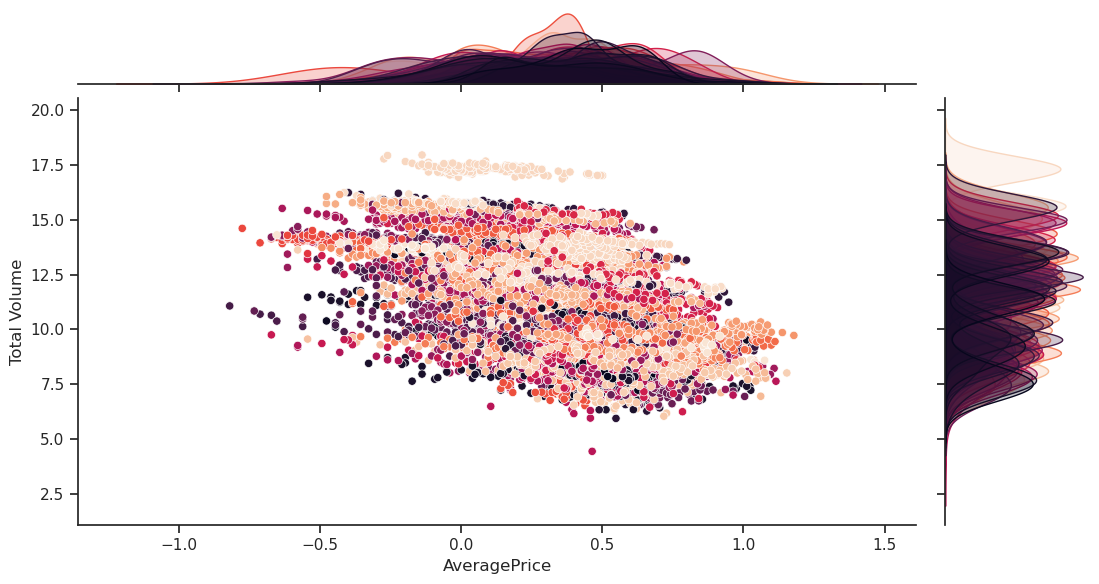

In [7]:
plot=sns.jointplot(df, x=T, y=Y, hue="region", legend=None, palette="rocket");
plot.fig.set_figwidth(12)

This looks fairly linear grouped by different regions and organic vs conventional.

In [8]:
data = pd.DataFrame(pd.concat([Y, X, T], axis=1))

In [9]:
import statsmodels.formula.api as smf
import statsmodels.api as sma
import statsmodels as sm

First let's take a naive view and estimate the price elasticity coefficient from the formula above.

In [10]:
model = smf.ols('Q("Total Volume") ~ AveragePrice', data = data).fit(cov_type='cluster', cov_kwds={'groups': data['region'], 'use_correction':True})
model.summary(slim=True)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Q("Total Volume")   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.351
No. Observations:               18249   F-statistic:                     318.2
Covariance Type:              cluster   Prob (F-statistic):           4.65e-24
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       12.7208      0.204     62.434      0.000      12.321      13.120
AveragePrice    -4.6882      0.263    -17.839      0.000      -5.203      -4.173
================================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

 <br/><br/>
 According to this view each $1\%$ increase in price is associated with a $-4.7\%$ drop in sales. That's all well and good, and would be a valid conclusion if you were trying to predict volumes on a similar dataset in the future. We can't claim a causal relationship though since we haven't reasoned around the causal graph, confounders etc.

I will assume X are counfounding factors that affect both the price and the volume sold. There are some important features that can explain both the average avocado price, and the population & relative appetite for avocados.

Now let's assume a linear model where we include the region, avocado type and time.

In [11]:
model = smf.ols('Q("Total Volume") ~ AveragePrice + C(region) + AveragePrice*C(type) + C(year)*C(month) + PropSmall', data = data).fit(cov_type='cluster', cov_kwds={'groups': data['region'], 'use_correction':True})

In [12]:
print(f"Log-log price elasticity (ATE): {model.params["AveragePrice"]:.2f}")

Log-log price elasticity (ATE): -1.39


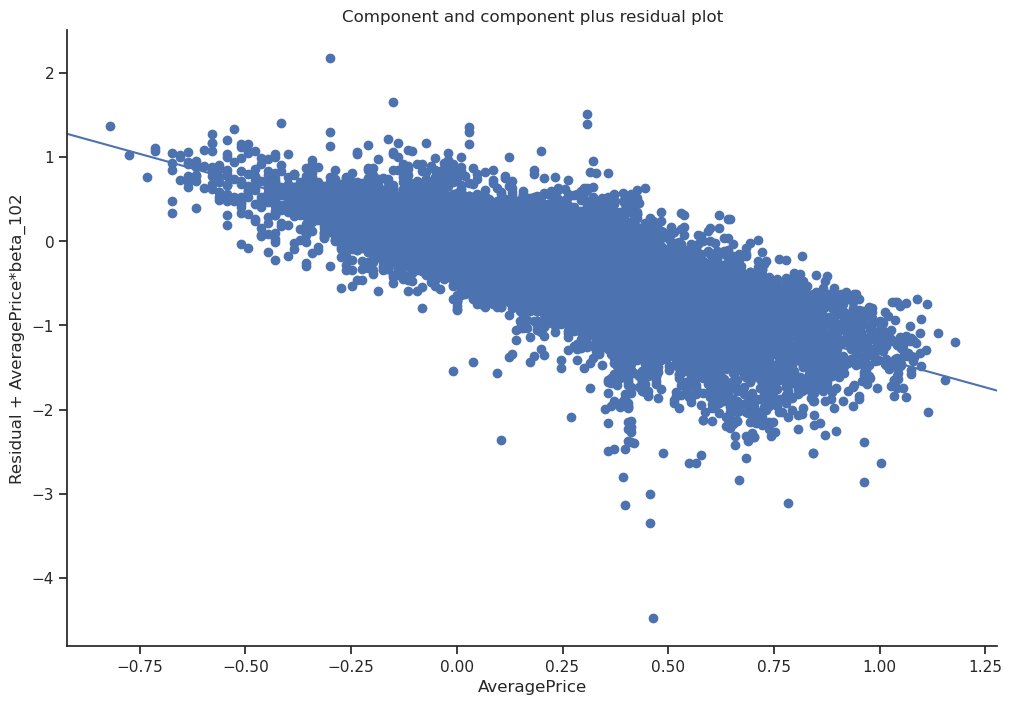

In [13]:
sma.graphics.plot_ccpr(model, "AveragePrice");

With this model, controlling for confounders we instead found a $-1.4\%$ drop in sales. Turns out the previous estimate was counfounded by X. Some regions have more expensive avocados and fewer buyers as a baseline, the previous estimate doesn't help us understand what would happen if we were to change the price in Boston. By controlling for confounders we are isolating the variance between price and sales caeteris paribus, and the causal relationship emerged. 

Any Data Scientist worth their salt would have included these features in a ML model anyway, the key difference is that we made a causal assumption about confounders and ruled out any mediators which lets us present this as a causal effect and not just correlation. There are other problems that can arise with applying Machine Learning to problems like this, you have to be aware of biases from regularization, overfitting and weak treatment effects ignored by the model. Linear regression automatically partials out any confounding effects, which is why it's so suitable for causal analyses. 

There are causal ML approaches such as metalearners and Double Machine Learning that can mitigate these flaws. Fundamentally we are no longer trying to optimize predictive power (your usual loss function), we are *just* interested in the marginal effects of the treatment on the outcome. *Beware of applying ML naively to these problems, the best predictor is not necessarily the best causal model*.

For fun, let's use these insights to set the right price depending on our wholesale avocado costs. Here's a simulation for some different cases.

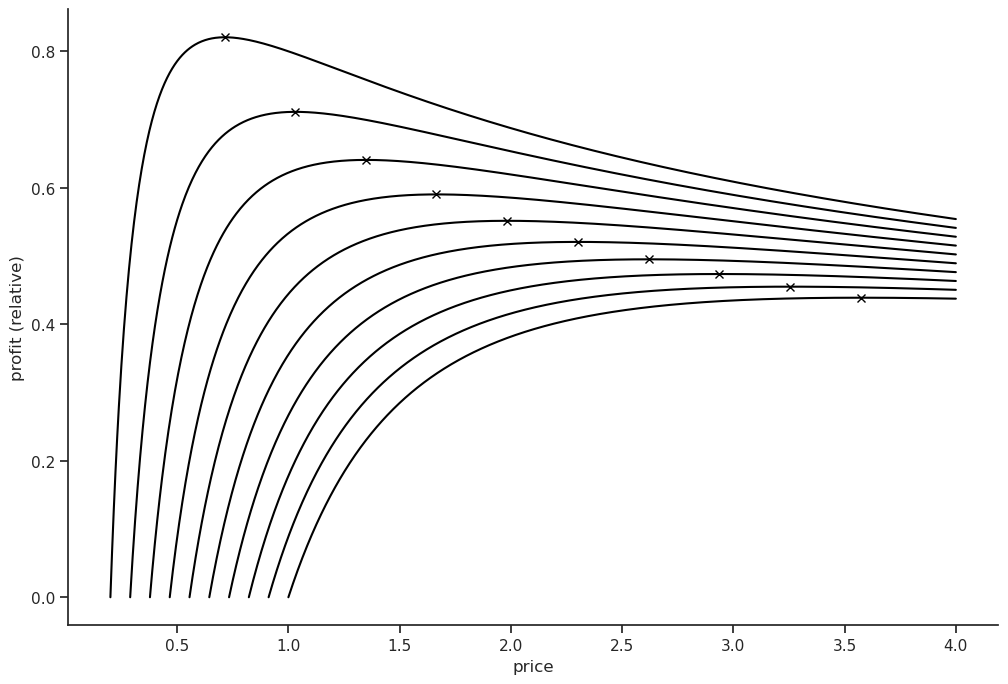

In [14]:

for wholesale_cost in np.linspace(0.2, 1, 10):
    prices = np.linspace(wholesale_cost,4, 1000)
    logsales = np.log(prices) * model.params["AveragePrice"]
    profit = np.exp(logsales)*(prices-wholesale_cost)

    plt.plot(prices, profit, color="black")

    optimal_price_idx = np.argmax(profit)
    optimal_price = prices[optimal_price_idx]
    plt.plot(optimal_price, np.max(profit),'x', color="black")
plt.xlabel("price");
plt.ylabel("profit (relative)");

The optimal price can be found using the criterion $\partial{\text{Profit}}=0$

$$\text{P} = S(p)(p-c) \implies \frac{\partial{P}}{\partial{p}} = \frac{\partial{S}}{\partial{p}}(p-c)+S(p) \implies p^* = c-\frac{S}{\frac{\partial{S}}{\partial{p}}}$$

$\frac{\partial{S}}{\partial{p}}$ is the market price elasticity. Using our simple model we get the following expression for the optimal price.

$$p^* =  c-\frac{\alpha p^\beta}{\beta \alpha p^{\beta-1}} = c - \frac{p^*}{\beta} \implies p^* = \frac{c}{1+ \frac{1}{\beta}}$$

Should retailers adopt this model? Probably not, I assumed we were an avocado monopolist, in the real world we would probably have competition and would have to set a lower price. This causal effect is valid for the average market price, which we don't set unless we have a monopoly. We would have to estimate our firm's price elasticity which is higher than the market's, either through experimentation or using additional data on competitor prices, market share & dispersion etc. Goes to show there are alway unmeasured confounders out there.

Some good resources on causality

[Causal Inference for The Brave and True](https://matheusfacure.github.io/python-causality-handbook/landing-page.html)

[Applied Causal Inference Powered by ML and AI](https://causalml-book.org/)